# Ligand-Receptor Interaction Correlation (LRIC) - Multi-sample


This notebook extends the cross-PCF and LRIC workflows introduced [in this tutorial](./LRIC_tutorial.ipynb) to multi-sample spatial analysis. Rather than analysing a single tissue section, the methods are applied across multiple samples to evaluate the consistency and variability of spatial cell-type organisation and ligand–receptor enrichment between sections.

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from itertools import islice
import copy
from scipy import sparse
import os

import liana as li

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

We use Xenium 5K spatial transcriptomics samples from [McGregor et al., 2025, *Spatial fibroblast niches define Crohn's fistulae*, Nature](https://doi.org/10.1038/s41586-025-09744-y), a subcellular-resolution spatial atlas of intestinal fistulae in Crohn's disease. Samples are annotated by tissue `TYPE` (healthy control, ulcer, fistula) and `LOCATION` (colon, ileum), with cell types provided under `CellAnnotation.Level0`.

The helper below loads one sample: it keeps annotated cells, filters low-count cells/genes, stores raw counts, normalises and log-transforms expression, and subsets to highly variable genes.

In [ ]:
import pooch

# Crohn's fistula Xenium 5K, per-sample AnnData (CC BY 4.0)
REGISTRY = {
    "RUN1_SLIDE1_S3.h5ad": ("https://ndownloader.figshare.com/files/67053323", "md5:cdaeab2f20a37f3431087843286e9845"),
    "RUN1_SLIDE2_S7.h5ad": ("https://ndownloader.figshare.com/files/67053341", "md5:4776a493d0d7d487fe9c091fd87055ce"),
    "RUN2_SLIDE1_S5.h5ad": ("https://ndownloader.figshare.com/files/67053353", "md5:3e6d6c2d12ecdf8de4dd07aa990edc24"),
    "RUN3_SLIDE1_S4.h5ad": ("https://ndownloader.figshare.com/files/67053374", "md5:e2f775c1a3f48016ba564a49c25a56ff"),
    "RUN3_SLIDE1_S5.h5ad": ("https://ndownloader.figshare.com/files/67053377", "md5:b67070e3ee2f9cf0ceb29ab21510f026"),
    "RUN3_SLIDE1_S7.h5ad": ("https://ndownloader.figshare.com/files/67053383", "md5:b3594e1558ae4f4482ab5859478c058b"),
}

def _resolve(sample_id, data_dir=None):
    """Local file if data_dir is given and it exists, else download+cache from Figshare."""
    if data_dir and (Path(data_dir) / f"{sample_id}.h5ad").exists():
        return str(Path(data_dir) / f"{sample_id}.h5ad")
    url, known_hash = REGISTRY[f"{sample_id}.h5ad"]
    return pooch.retrieve(url, known_hash=known_hash, fname=f"{sample_id}.h5ad",
                          path=pooch.os_cache("crohns_xenium5k"))

In [3]:
def load_crohn_slide(
    sample_id: str,
    data_dir: str | None = None,          # None -> Figshare (public); pass your cluster path for local speed
    n_top_genes: int = 3000,
    labels_key: str = "CellAnnotation.Level0",
):
    adata = sc.read_h5ad(_resolve(sample_id, data_dir))
    adata.obs_names_make_unique()
    adata = adata[adata.obs[labels_key].notna()].copy()

    sc.pp.filter_cells(adata, min_counts=3)
    sc.pp.filter_genes(adata, min_counts=3)

    adata.obs[labels_key] = adata.obs[labels_key].astype("category")
    adata.obsm["spatial"] = adata.obs[["x", "y"]].values

    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, layer="counts", flavor="seurat_v3",
                                n_top_genes=min(n_top_genes, adata.n_vars), subset=True)
    return adata

In [4]:
sample_ids = ["RUN1_SLIDE1_S3", "RUN1_SLIDE2_S7", "RUN2_SLIDE1_S5", "RUN3_SLIDE1_S4", "RUN3_SLIDE1_S7", "RUN3_SLIDE1_S5"]
adata_list = [load_crohn_slide(sample_id, data_dir="../data") for sample_id in sample_ids]

## Ligand–Receptor Database (Human)

In [5]:
resource = li.rs.select_resource('consensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

4624 LR pairs in resource


,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


## Run cross PCF and LRIC

In [6]:
### set variables
spatial_key = "spatial"
cell_type_key = "CellAnnotation.Level0"
annulus_width = 20
radius_step = 20

In [7]:
for ad in adata_list:
    li.mt.cross_pcf(ad, 
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            key_added="cross_pcf")

    li.mt.lric(
            ad,
            resource=resource,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask ligand/receptor pairs expressed in <2% of cells
            use_raw=False,
            key_added="lric_ag",  #results will be saved under this label in adata.uns
            verbose=True,
        )

    li.mt.lric(
            ad,
            resource=resource,
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask sender/receiver-celltype pairs expressed in <2% of that celltype
            use_raw=False,
            key_added="lric_ct", #results will be saved under this label in adata.uns
            verbose=True,
        )

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 103899 cells (min_cells=1039).
Using `.X`!
The following cell identities were excluded: B-Cells, Lymphatics, Neurons, Neutrophils


Using provided `resource`.


Running LRIC (conditional within-type null) for 11 cell types (110 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████| 110/110 [02:50<00:00,  1.55s/it]
Using `.X`!


...

Running LRIC (conditional within-type null) for 12 cell types (132 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████| 132/132 [00:50<00:00,  2.61it/s]
Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.
`min_cells=None`: dropping cell types with <= 1.0% of 81825 cells (min_cells=819).
Using `.X`!
The following cell identities were excluded: Neurons


Using provided `resource`.


Running LRIC (conditional within-type null) for 14 cell types (182 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████| 182/182 [01:31<00:00,  2.00it/s]


## Ranking interactions using AUC–log2 score

**Read it as:** `> 0` co-enriched, `< 0` depleted, `≈ 0` random. The magnitude
is a fold-change (`2**score`, so `1` ≈ 2×).

In [8]:
HALF_ANNULUS = annulus_width / 2         # inner-edge radius -> annulus centre
G_FLOOR      = 0.05                      # floor on g(r) before log2 (keeps empty/depleted bins finite)
GROUP_COLORS = {
    "FISTULA": "#009E73",
    "HC": "#6A51A3"}

def _log2g(curve):
    """log2 g(r), g floored at G_FLOOR to keep empty/depleted bins finite."""
    return np.log2(np.maximum(np.asarray(curve, float), G_FLOOR))
def _iter_features(adata, modality):
    """Yield (feature_key, g(r) profile) for every feature in adata.uns[modality]."""
    d = adata.uns[modality]; r = np.asarray(d["radii"], float)
    if modality == "cross_pcf":                       # symmetric: emit each unordered pair once
        seen = set()
        for k, c in d["results"].items():
            if frozenset(k) not in seen and not seen.add(frozenset(k)):
                yield k, np.asarray(c, float).ravel()
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == r.size else M.T
        for j, lr in enumerate(d["pair_names"]): yield lr, M[:, j]
    elif modality == "lric_ct":
        for k, a in d["results"].items():
            A = np.asarray(a, float); A = A if A.shape[0] == r.size else A.T
            for j, lr in enumerate(d["pair_names"]): yield (k, lr), A[:, j]
    else:
        raise ValueError(f"unknown modality {modality!r}")

def _feature_label(feat, modality):
    if modality == "cross_pcf": return f"{feat[0]} ↔ {feat[1]}"
    if modality == "lric_ag":   return feat.replace("^", " → ")
    (a, b), lr = feat;          return f"{a} → {b}\n{lr.replace('^', ' → ')}"

def auc_log2_score(adata, modality, max_dist=None, normalize=True, min_bins=3):
    """(Mean) area under log2 g(r) — one signed score per interaction.

    >0 co-enriched, <0 depleted, 0 = random. `modality` is one of
    "cross_pcf"/"lric_ag"/"lric_ct" or any iterable of them; multiple ->
    one long frame with a `modality` column.

    max_dist  : integrate only over r < max_dist (radius units); None -> all r.
    normalize : True  -> integral / radial span = mean log2 FC (comparable across samples);
                False -> raw integral (log2 * radius units; single-sample).
    min_bins  : drop pairs with < this many finite log2 g(r) in the window
                (support gate; catches expr_prop-masked & degenerate pairs).
    """
    mods = [modality] if isinstance(modality, str) else list(modality)
    rows = []
    for mod in mods:
        radii = np.asarray(adata.uns[mod]["radii"], float)
        x_all = radii + HALF_ANNULUS
        win = radii < max_dist if max_dist is not None else np.ones(radii.size, bool)
        for key, curve in _iter_features(adata, mod):
            y = _log2g(np.asarray(curve, float))
            m = win & np.isfinite(y) & np.isfinite(x_all)
            if m.sum() < min_bins:                       # support gate
                continue
            x, yv = x_all[m], y[m]
            span = x.max() - x.min()
            area = np.trapezoid(yv, x)
            rows.append({
                "modality": mod,
                "feature": key,
                "label": _feature_label(key, mod).replace("\n", "  "),
                "score": area / span if (normalize and span > 0) else area,
            })
    cols = ["modality", "feature", "label", "score"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows, columns=cols).sort_values("score", ascending=False, ignore_index=True)

In [9]:
def auc_across_samples(adata_list, modality, *, sample_key=None, group_key=None, **kw):
    """auc_log2_score on every sample, stacked into one tidy long frame for cross-sample
    boxplots. modality: one name or an iterable (stacked w/ a `modality` column).
    sample_key/group_key: obs columns (constant per sample). **kw -> auc_log2_score."""
    out = []
    for i, ad in enumerate(adata_list):
        df = auc_log2_score(ad, modality, **kw)
        df.insert(0, "sample", str(ad.obs[sample_key].iloc[0]) if sample_key else f"S{i}")
        if group_key: df.insert(1, "group", str(ad.obs[group_key].iloc[0]))
        out.append(df)
    return pd.concat(out, ignore_index=True)

In [10]:
from scipy.stats import mannwhitneyu

def _bh(p):
    """Benjamini–Hochberg FDR (self-contained; no statsmodels dependency)."""
    p = np.asarray(p, float); n = p.size; o = np.argsort(p)
    r = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(r, 0, 1); return out

def group_test(auc_df, a="FISTULA", b="HC", min_n=2):
    """Per (modality, feature): Mann–Whitney U on the AUC scores (a vs b) + rank-biserial
    effect size + BH-FDR. rb>0 => `a` higher; rb=±1 => groups separate completely. Ranked
    by |rb| then p. (At ~3 samples/group the smallest two-sided p is ~0.1 — read the effect
    size, not just p.) Returns one row per feature."""
    rows = []
    for (mod, lab), g in auc_df.groupby(["modality", "label"], sort=False):
        xa = g.score[g.group == a].dropna().values; xb = g.score[g.group == b].dropna().values
        if len(xa) < min_n or len(xb) < min_n: continue
        U, p = mannwhitneyu(xa, xb, alternative="two-sided")
        feat = g.feature.iloc[0] if "feature" in g.columns else lab
        rows.append(dict(modality=mod, label=lab, feature=feat, n_a=len(xa), n_b=len(xb),
                         delta=float(xa.mean() - xb.mean()), rb=float(2 * U / (len(xa) * len(xb)) - 1), p=float(p)))
    res = pd.DataFrame(rows)
    if len(res):
        res["padj"] = _bh(res.p)
        res = (res.assign(_k=res.rb.abs()).sort_values(["_k", "p"], ascending=[False, True])
                  .drop(columns="_k").reset_index(drop=True))
    return res

def plot_group_boxplots(auc_df, res, modality, top_n=5, a="FISTULA", b="HC", colors=None, figsize=None):
    """Faceted boxplots of the top-N features by effect size: AUC score per group, points
    overlaid, dashed line at 0 (= random). Keeps the GROUP_COLORS palette."""
    colors = colors or GROUP_COLORS
    d = res[res.modality == modality].head(top_n); n = len(d); rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, n, figsize=figsize or (3.0 * n, 3.4), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), d.iterrows()):
        sub = auc_df[(auc_df.modality == modality) & (auc_df.label == row.label)]
        data = [sub.score[sub.group == g].dropna().values for g in (a, b)]
        bp = ax.boxplot(data, widths=.6, patch_artist=True, showcaps=False,
                        medianprops=dict(color="black", lw=1.2), whiskerprops=dict(color="0.5"),
                        flierprops=dict(marker=""))
        for patch, g in zip(bp["boxes"], (a, b)): patch.set(facecolor=colors[g], alpha=.35, edgecolor="0.5")
        for i, (g, v) in enumerate(zip((a, b), data), 1):
            ax.scatter(i + rng.uniform(-.08, .08, len(v)), v, color=colors[g], edgecolor="white", s=34, lw=.5, zorder=3)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_xticks([1, 2]); ax.set_xticklabels([a, b])
        name = _feature_label(row.feature, modality) if isinstance(row.feature, tuple) else row.label
        ax.set_title(f"{name}\nrb={row.rb:.2f}  p={row.p:.2g}  padj={row.padj:.2g}", fontsize=8)
        ax.set_ylabel("log2 g(r) summary", fontsize=8); ax.tick_params(labelsize=8)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    h = [plt.Line2D([0], [0], marker="o", ls="", markerfacecolor=colors[g], markeredgecolor="w",
                    markersize=8, label=g) for g in (a, b)]
    fig.legend(handles=h, title="TYPE", loc="center right", frameon=False, fontsize=8)
    fig.suptitle(f"{modality}: top {n} features ({a} vs {b})", y=1.03)
    fig.tight_layout(rect=[0, 0, .9, 1]); return fig

> _Note regarding sample size_:  This example has only three samples per group. With `n = 3 vs. 3`, the smallest attainable two-sided Mann-Whitney p-value is `0.10` (reached when the two groups are perfectly separated), so no single feature can cross a conventional `p < 0.05` threshold and all BH-FDR values stay `≥ ~0.1`. The comparison is therefore exploratory: use the rank-biserial effect size to prioritise features and treat the hits as hypothesis-generating rather than confirmatory.

In [39]:
auc_df = auc_across_samples(
    adata_list, ("cross_pcf", "lric_ag", "lric_ct"),
    sample_key="SAMPLE", group_key="TYPE", max_dist=100)   # normalize=True (default)


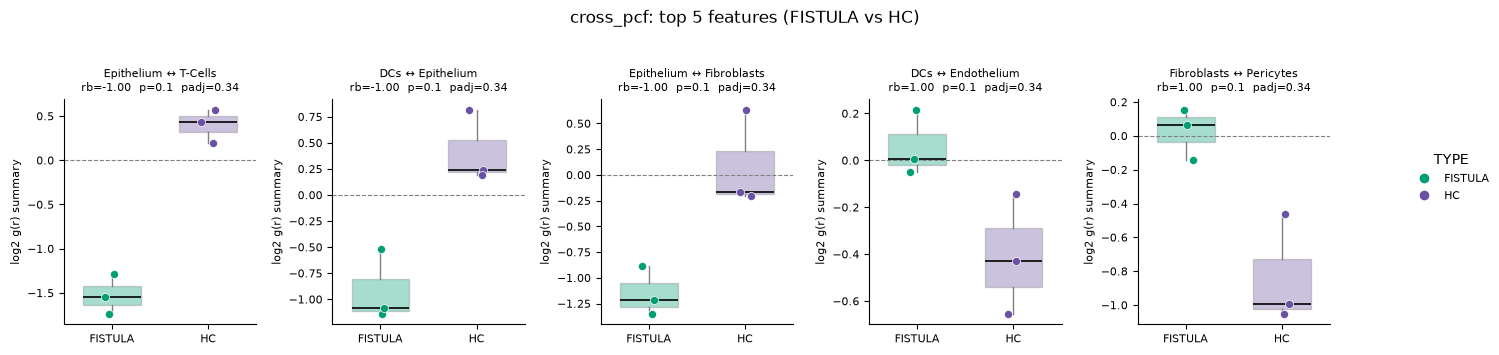

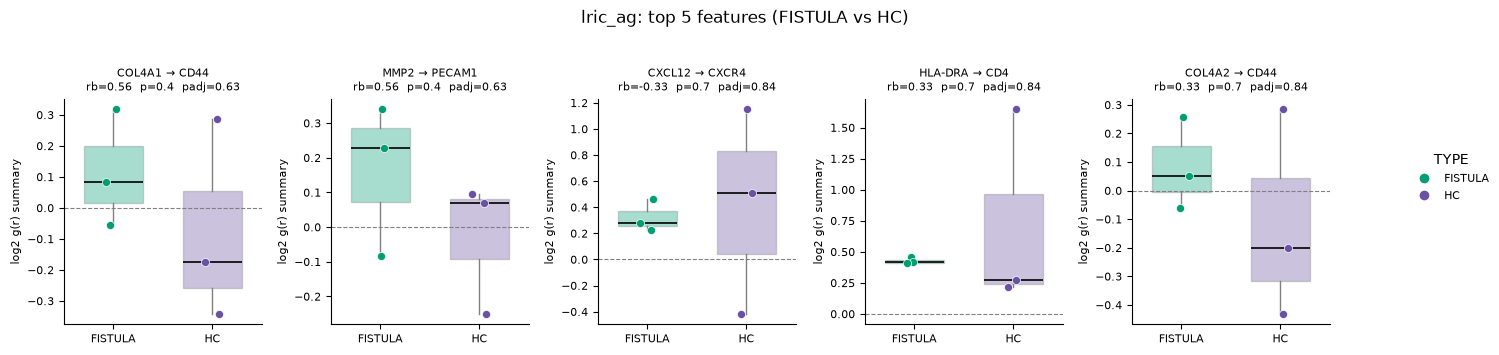

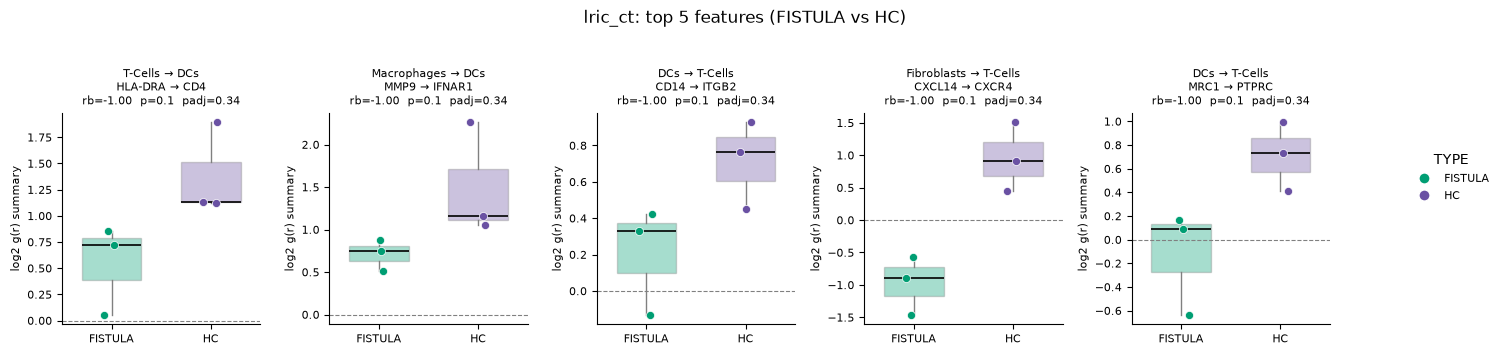

In [12]:
res = group_test(auc_df, min_n=3)                 # Mann–Whitney + rank-biserial + BH-FDR, per (modality, feature)

for mod in ("cross_pcf", "lric_ag", "lric_ct"):
    plot_group_boxplots(auc_df, res, mod, top_n=5) 

## Comparing full interaction curves using divergence

**Read it as:** divergence `≈ 0` means the two interactions have similar spatial profiles across samples, while a larger value means they differ more strongly across distance.

In [13]:
def _pair_data(adata, modality, fa, fb, max_dist=None, min_bins=3):
    ads = [adata] if hasattr(adata, "uns") else list(adata); x0, A, B = None, [], []
    def get(ad, f):
        for k, y in _iter_features(ad, modality):
            if k == f or modality == "cross_pcf" and frozenset(k) == frozenset(f): return _log2g(y)
        raise KeyError(f"{f!r} not found in {modality!r}")
    for ad in ads:
        r = np.asarray(ad.uns[modality]["radii"], float)
        if x0 is not None and not np.allclose(r, x0): raise ValueError("Radii differ between samples.")
        x0 = r; A.append(get(ad, fa)); B.append(get(ad, fb))
    x, A, B = x0 + HALF_ANNULUS, np.vstack(A), np.vstack(B)
    keep = np.isfinite(x) & np.isfinite(A).all(0) & np.isfinite(B).all(0)
    if max_dist is not None: keep &= x0 < max_dist
    if keep.sum() < min_bins: raise ValueError(f"Only {keep.sum()} shared finite bins.")
    return x[keep], A[:, keep], B[:, keep]


def divergence_log2(adata, modality, feature_a, feature_b, *, max_dist=None, normalize=True, min_bins=3):
    x, A, B = _pair_data(adata, modality, feature_a, feature_b, max_dist, min_bins)
    d = (A - B).mean(0); scale = x[-1] - x[0] if normalize and x[-1] > x[0] else 1
    T = np.trapezoid(abs(d), x) / scale; j = np.argmax(abs(d))
    return pd.Series({
        "modality": modality, "feature_a": feature_a, "feature_b": feature_b,
        "label_a": _feature_label(feature_a, modality).replace("\n", "  "),
        "label_b": _feature_label(feature_b, modality).replace("\n", "  "),
        "divergence": T, "r_star": x[j], "delta_star": d[j],
        "direction": "A > B" if d[j] > 0 else "B > A" if d[j] < 0 else "equal",
        "n_samples": len(A), "max_dist": max_dist, "normalize": normalize, "min_bins": min_bins
    })


def plot_pair_divergence(adata, res, figsize=(7, 4.5)):
    x, A, B = _pair_data(adata, res.modality, res.feature_a, res.feature_b, res.max_dist, res.min_bins)
    ma, mb = A.mean(0), B.mean(0); fig, ax = plt.subplots(figsize=figsize)
    ax.fill_between(x, ma, mb, color="0.6", alpha=.35, lw=0, label="divergence")
    for M, mu, col, lab in ((A, ma, "#009E73", res.label_a), (B, mb, "#6A51A3", res.label_b)):
        sd = M.std(0); ax.fill_between(x, mu-sd, mu+sd, color=col, alpha=.15, lw=0)
        ax.plot(x, mu, color=col, lw=2, label=f"{lab} (mean ± SD)")
    ax.axvline(res.r_star, color="black", ls=":", lw=1); ax.axhline(0, color="grey", ls="--", lw=.8)
    ax.set(title=f"{res.modality}: div={res.divergence:.3g}  r*={res.r_star:.0f} µm",
           xlabel="radius r (µm)", ylabel="log2 g(r)")
    ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False); fig.tight_layout()
    return fig

In [20]:
def _group_curve_data(adatas, modality, feature, max_dist, min_bins):
    def get(ad):
        for k, y in _iter_features(ad, modality):
            if k == feature or (modality == "cross_pcf" and frozenset(k) == frozenset(feature)): return _log2g(y)
        return None
    x0, C = None, []
    for ad in adatas:
        y = get(ad)
        if y is None: continue
        r = np.asarray(ad.uns[modality]["radii"], float)
        if x0 is not None and not np.allclose(r, x0): raise ValueError("Radii differ between samples.")
        x0 = r; C.append(y)
    if not C: raise KeyError(f"{feature!r} not found in any sample for {modality!r}")
    x, C = x0 + HALF_ANNULUS, np.vstack(C)
    keep = np.isfinite(x) & np.isfinite(C).any(0) & (x0 < max_dist if max_dist is not None else True)
    if keep.sum() < min_bins: raise ValueError(f"Only {keep.sum()} shared finite bins.")
    return x[keep], C[:, keep]


def plot_group_feature(adata_list, modality, feature, *, group_key, groups=None,
                       max_dist=None, min_bins=3, band="sd", colors=None, figsize=(7, 4.5)):
    colors = colors or GROUP_COLORS
    labels = [str(ad.obs[group_key].iloc[0]) for ad in adata_list]
    fig, ax = plt.subplots(figsize=figsize)
    for g in groups or dict.fromkeys(labels):
        members = [ad for ad, lab in zip(adata_list, labels) if lab == g]
        x, C = _group_curve_data(members, modality, feature, max_dist, min_bins)
        mu, col = np.nanmean(C, 0), colors.get(g)
        lo, hi = (np.nanmin(C, 0), np.nanmax(C, 0)) if band == "range" else (mu - np.nanstd(C, 0), mu + np.nanstd(C, 0))
        ax.fill_between(x, lo, hi, color=col, alpha=.15, lw=0)
        ax.plot(x, mu, color=col, lw=2, label=f"{g} (n={C.shape[0]})")
    ax.axhline(0, color="grey", ls="--", lw=.8)
    ax.set(title=_feature_label(feature, modality).replace("\n", "  "), xlabel="radius r (µm)", ylabel="log2 g(r)")
    ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False); fig.tight_layout()
    return fig

In [ ]:
# ----------- Plotting helpers for spatial scatterplots of cell types -----------

C_TOP, C_BOT, C_REST = "#009E73", "#D55E00", "#BBBBBB"
def _clean(ax):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
def _grey(ax, xy, s): ax.scatter(*xy.T, s=s * .35, c="#E9E9E9", linewidths=0, rasterized=True)
def _panel_types(ax, coords, types, a, b, s):
    _grey(ax, coords[~np.isin(types, (a, b))], s)
    for ct, col in ((a, C_TOP), (b, C_BOT)):
        m = types == ct
        ax.scatter(*coords[m].T, s=s, c=col, linewidths=0, label=f"{ct}  (n={int(m.sum())})", rasterized=True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=8,
              markerscale=2, frameon=False); _clean(ax)
    
def plot_spatial_types_grid(adata_list, type_a, type_b, celltype_key, *, group_key="TYPE",
                            sample_key="SAMPLE", groups=None, spatial_key="spatial", s=6, figsize=None):
    labels = [str(ad.obs[group_key].iloc[0]) for ad in adata_list]
    order = groups or list(dict.fromkeys(labels))
    rows = [[ad for ad, lab in zip(adata_list, labels) if lab == g] for g in order]
    ncol = max(len(r) for r in rows)
    fig, axes = plt.subplots(len(order), ncol, figsize=figsize or (4 * ncol, 4 * len(order)), squeeze=False)
    for axrow, g, members in zip(axes, order, rows):
        for ax, ad in zip(axrow, members):
            _panel_types(ax, np.asarray(ad.obsm[spatial_key], float), ad.obs[celltype_key].astype(str).values, type_a, type_b, s)
            ax.set_title(str(ad.obs[sample_key].iloc[0]), fontsize=10)
        for ax in axrow[len(members):]: ax.axis("off")
        axrow[0].annotate(g, xy=(-.18, .5), xycoords="axes fraction", fontsize=12, fontweight="bold",
                          ha="right", va="center", rotation=90)
    fig.tight_layout()
    return fig

### CrossPCF

In [32]:
auc_df  = auc_across_samples(adata_list, "cross_pcf", group_key="TYPE")
ranked  = group_test(auc_df, a="FISTULA", b="HC")          
ranked.head(3)                                            

,modality,label,feature,n_a,n_b,delta,rb,p,padj
0,cross_pcf,Epithelium ↔ T-Cells,"(Epithelium, T-Cells)",3,3,-1.704912,-1.0,0.1,0.441379
1,cross_pcf,DCs ↔ Epithelium,"(DCs, Epithelium)",3,3,-1.128927,-1.0,0.1,0.441379
2,cross_pcf,Epithelium ↔ Fibroblasts,"(Epithelium, Fibroblasts)",3,3,-1.066823,-1.0,0.1,0.441379


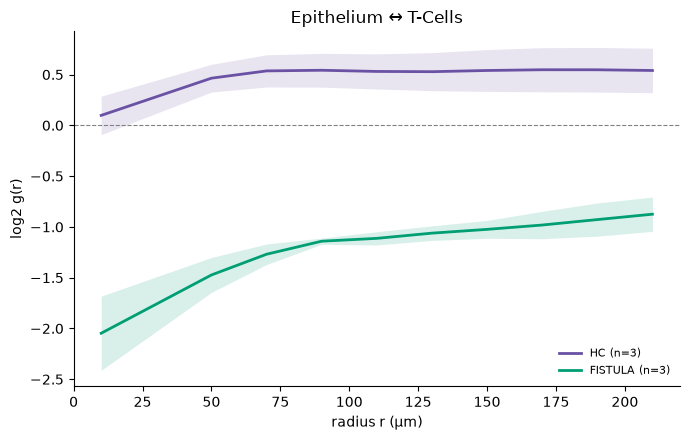

In [33]:
plot_group_feature(adata_list, "cross_pcf", ("Epithelium", "T-Cells"), group_key="TYPE");

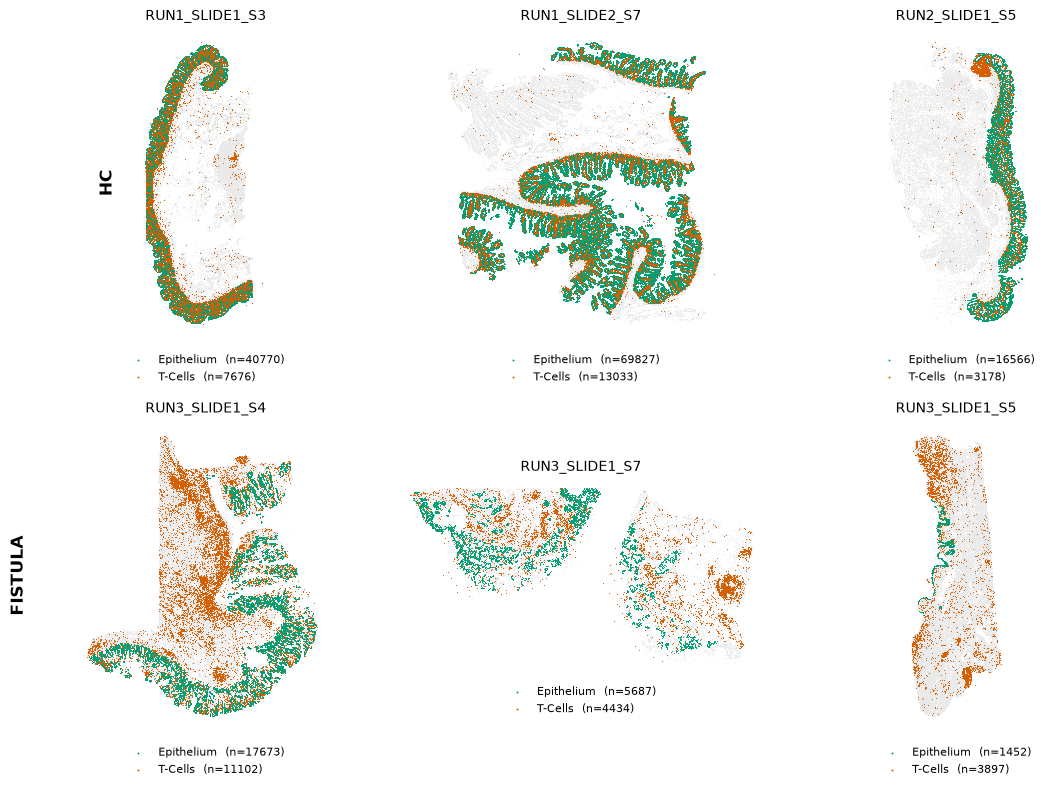

In [34]:
plot_spatial_types_grid(adata_list, "Epithelium", "T-Cells", cell_type_key, group_key="TYPE", s=0.5);

### agnostic LRIC

In [35]:
auc_df  = auc_across_samples(adata_list, "lric_ag", group_key="TYPE", min_bins=3)
ranked  = group_test(auc_df, a="FISTULA", b="HC")       
ranked.head(3)                                             

,modality,label,feature,n_a,n_b,delta,rb,p,padj
0,lric_ag,CXCL14 → CXCR4,CXCL14^CXCR4,2,3,-2.088117,-1.0,0.2,0.625
1,lric_ag,COL18A1 → ITGB5,COL18A1^ITGB5,2,3,0.462642,1.0,0.2,0.625
2,lric_ag,GAS6 → AXL,GAS6^AXL,2,3,0.285224,1.0,0.2,0.625


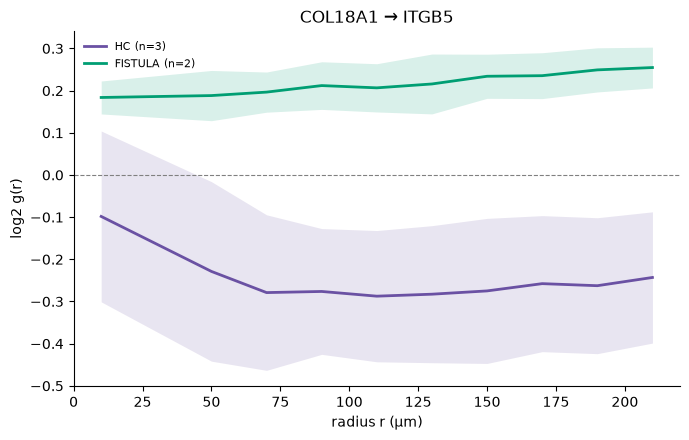

In [36]:
plot_group_feature(adata_list, "lric_ag", "COL18A1^ITGB5", group_key="TYPE");

### CT-informed LRIC

In [37]:
auc_df  = auc_across_samples(adata_list, "lric_ct", group_key="TYPE", min_bins=3)
ranked  = group_test(auc_df, a="FISTULA", b="HC")       
ranked.head(3)                                             

,modality,label,feature,n_a,n_b,delta,rb,p,padj
0,lric_ct,T-Cells → DCs HLA-DRA → CD4,"((T-Cells, DCs), HLA-DRA^CD4)",3,3,-0.590572,-1.0,0.1,0.612177
1,lric_ct,Fibroblasts → T-Cells CXCL14 → CXCR4,"((Fibroblasts, T-Cells), CXCL14^CXCR4)",3,3,-2.006756,-1.0,0.1,0.612177
2,lric_ct,DCs → T-Cells CD14 → ITGB2,"((DCs, T-Cells), CD14^ITGB2)",3,3,-0.336197,-1.0,0.1,0.612177


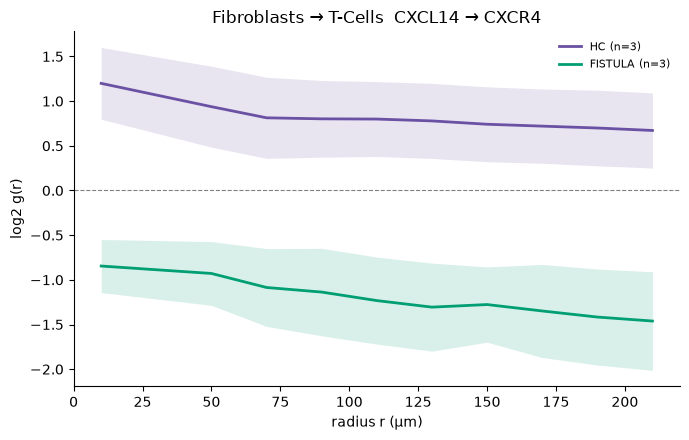

In [38]:
plot_group_feature(adata_list, "lric_ct", (("Fibroblasts", "T-Cells"), "CXCL14^CXCR4"), group_key="TYPE");

---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>